In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [23]:
x_train = np.linspace(-1, 1, 20)

In [24]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [25]:
x_test = np.linspace(-1, 1, 20)

In [26]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

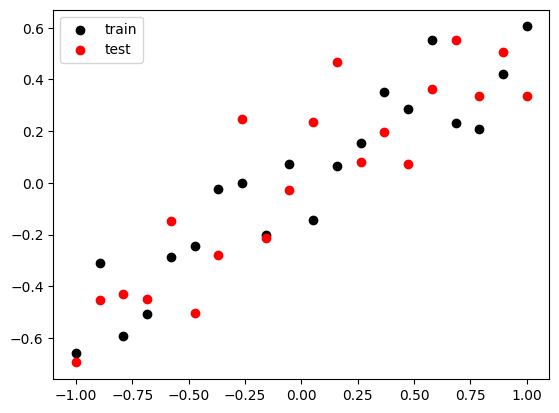

In [27]:
plt.scatter(x_train, y_train, label='train', c="black")
plt.scatter(x_test, y_test, label='test', c="red")
plt.legend()
plt.show()

In [28]:
model_1 = Sequential()

model_1.add(Dense(128, activation='relu', input_dim=1))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)
model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])
history = model_1.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=False)

In [29]:
_, train_mse = model_1.evaluate(x_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.00399748096242547, Test: 0.04629269987344742


In [30]:
y_pred = model_1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


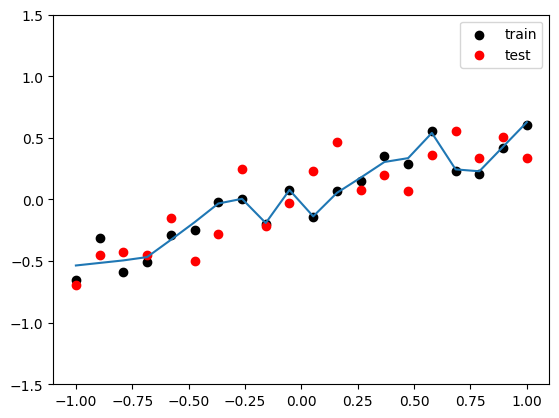

In [32]:
plt.figure()
plt.scatter(x_train, y_train, c='black', label='train')
plt.scatter(x_test, y_test, c='red', label='test')
plt.plot(x_test, y_pred)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

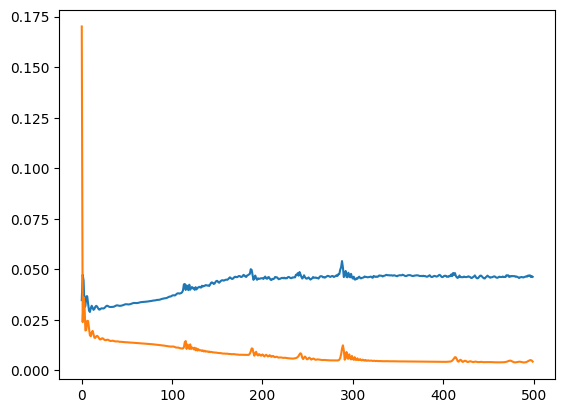

In [33]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])

In [ ]:
# As we can observe that model 1 is clearly overfitting so now we will solve this problem using dropout method

# **Dropout** **Model**

In [40]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=1))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.014698296785354614, Test: 0.035407595336437225


In [42]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


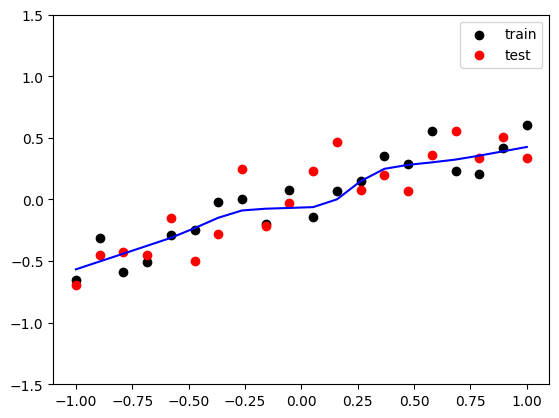

In [43]:
plt.figure()
plt.scatter(x_train, y_train, c='black', label='train')
plt.scatter(x_test, y_test, c='red', label='test')
plt.plot(x_test, y_pred, c='blue')
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

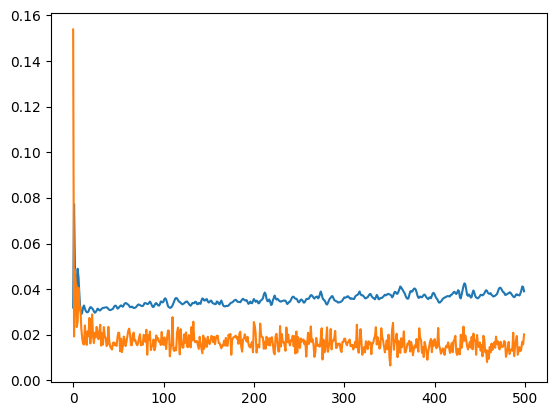

In [39]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])